In [5]:
import os
import sys
import matplotlib.pyplot as plt
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [6]:
import pandas as pd
import numpy as np
import src.features.seismic_features as sf

In [7]:
def process_real_catalog(dat_file):
    column_names = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Depth', 'Magnitude']
    df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')
    print(df)
    data_input = df.to_numpy()
    year = data_input[:, 0].astype(int)
    month = data_input[:, 1].astype(int)
    day = data_input[:, 2].astype(int)
    hour = data_input[:, 3].astype(int)
    minute = data_input[:, 4].astype(int)
    second = data_input[:, 5]
    
    data = np.column_stack((year, month, day, hour, minute, second))
    jd0 = sf.cal2jd([1970, 1, 1, 0, 0, 0])
    jd = np.array([sf.cal2jd(d) - jd0 for d in data])

    df.loc[:, 't'] = jd
    df['dt'] = df['t'].diff().shift(-1)
    df['ts'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce'  
    )
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt','ts']]
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    return df


In [8]:
base_dir = os.path.join(project_root,'data', 'ChinaArray')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df1 = process_real_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['ChinaArrary.dat']
         Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0        1970      1    1    12      55   16.00    26.050    100.980      0   
1        1970      1    2     6      14   14.60    38.100    119.470     26   
2        1970      1    2    10      56    0.00    37.200    114.830     17   
3        1970      1    2    13      45    5.00    40.300     77.000      0   
4        1970      1    2    18      56    0.00    35.700    122.500      0   
...       ...    ...  ...   ...     ...     ...       ...        ...    ...   
1495637  2023      8   13    23      17   37.45    37.922    115.216     12   
1495638  2023      8   13    23      27   38.85    37.916    115.246     26   
1495639  2023      8   13    23      29   35.34    24.327    101.880     15   
1495640  2023      8   13    23      29   59.71    23.850    114.501      9   
1495641  2023      8   13    23      49   13.80    29.726    106.016     13   

         Magnitude  
0         

In [9]:
df1['ts']

0         1970-01-01 12:55:16.000
1         1970-01-02 06:14:14.600
2         1970-01-02 10:56:00.000
3         1970-01-02 13:45:05.000
4         1970-01-02 18:56:00.000
                    ...          
1495637   2023-08-13 23:17:37.450
1495638   2023-08-13 23:27:38.850
1495639   2023-08-13 23:29:35.340
1495640   2023-08-13 23:29:59.710
1495641   2023-08-13 23:49:13.800
Name: ts, Length: 1495642, dtype: datetime64[ns]

In [10]:
base_dir = os.path.join(project_root,'data', 'ChuanDian')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df4 = process_real_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['Chuandian2021.dat']


        Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0       1970      1    1    12      55   16.00    26.050    100.980      0   
1       1970      1    5     1       0   34.00    24.100    102.600     13   
2       1970      1    5     1      32   40.00    24.200    102.450      0   
3       1970      1    5     1      46    0.00    24.200    102.450      0   
4       1970      1    5     1      57    0.00    24.200    102.450      0   
...      ...    ...  ...   ...     ...     ...       ...        ...    ...   
571126  2021      5   23    23      55   24.85    25.671     99.907      8   
571127  2021      5   23    23      55   43.49    25.690     99.900      8   
571128  2021      5   23    23      56   26.67    25.647     99.890      8   
571129  2021      5   23    23      57   12.92    25.687     99.905      8   
571130  2021      5   23    23      58   21.72    25.591    100.000      8   

        Magnitude  
0             2.7  
1             7.8  
2  

In [11]:
df4['ts']

0        1970-01-01 12:55:16.000
1        1970-01-05 01:00:34.000
2        1970-01-05 01:32:40.000
3        1970-01-05 01:46:00.000
4        1970-01-05 01:57:00.000
                   ...          
571126   2021-05-23 23:55:24.850
571127   2021-05-23 23:55:43.490
571128   2021-05-23 23:56:26.670
571129   2021-05-23 23:57:12.920
571130   2021-05-23 23:58:21.720
Name: ts, Length: 571131, dtype: datetime64[ns]

In [12]:
def process_synthetic_catlog(dat_file):
    column_names =["ID1", "ID2", "t", "Magnitude", "Depth", "Longitude", "Latitude"]
    df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')
    df['dt'] = df['t'].diff().shift(-1)
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt']]
    # 保存为同名csv文件
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    
    return df

In [13]:
base_dir = os.path.join(project_root,'data', 'AZDX-taper')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df2 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [14]:
print(df2)

               t  Magnitude  Latitude  Longitude   Depth      dt
0        708.562      4.753    29.196    102.273     0.0  10.578
1        719.140      4.754    29.277    102.278     0.0  27.101
2        746.241      5.012    29.169    102.272     0.0  11.272
3        757.513      4.754    29.277    102.278     0.0  12.913
4        770.426      4.754    29.169    102.272     0.0   9.094
...          ...        ...       ...        ...     ...     ...
48801  19999.500      4.717    26.579    103.007 -3000.0   0.200
48802  19999.700      4.742    26.500    103.030     0.0   0.100
48803  19999.800      4.750    25.590    103.248     0.0   0.100
48804  19999.900      4.716    27.686    102.892 -3000.0   0.500
48805  20000.400      4.747    27.232    102.616     0.0     NaN

[48806 rows x 6 columns]


In [15]:
base_dir = os.path.join(project_root,'data', 'AZDX')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df3 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [16]:
print(df3)

                t  Magnitude  Latitude  Longitude    Depth     dt
0         115.046      4.720    29.277    102.278 -18000.0  6.213
1         121.259      4.720    29.277    102.278 -18000.0  6.212
2         127.471      4.720    29.277    102.278 -18000.0  6.213
3         133.684      4.720    29.277    102.278 -18000.0  3.933
4         137.617      4.720    29.277    102.278 -15000.0  1.675
...           ...        ...       ...        ...      ...    ...
172841  19999.700      4.969    27.938    102.232  -6000.0  0.200
172842  19999.900      4.712    23.637    102.966 -18000.0  0.000
172843  19999.900      4.704    27.140    102.680 -18000.0  0.100
172844  20000.000      4.699    24.323    103.117 -18000.0  0.300
172845  20000.300      5.228    26.920    102.832 -18000.0    NaN

[172846 rows x 6 columns]


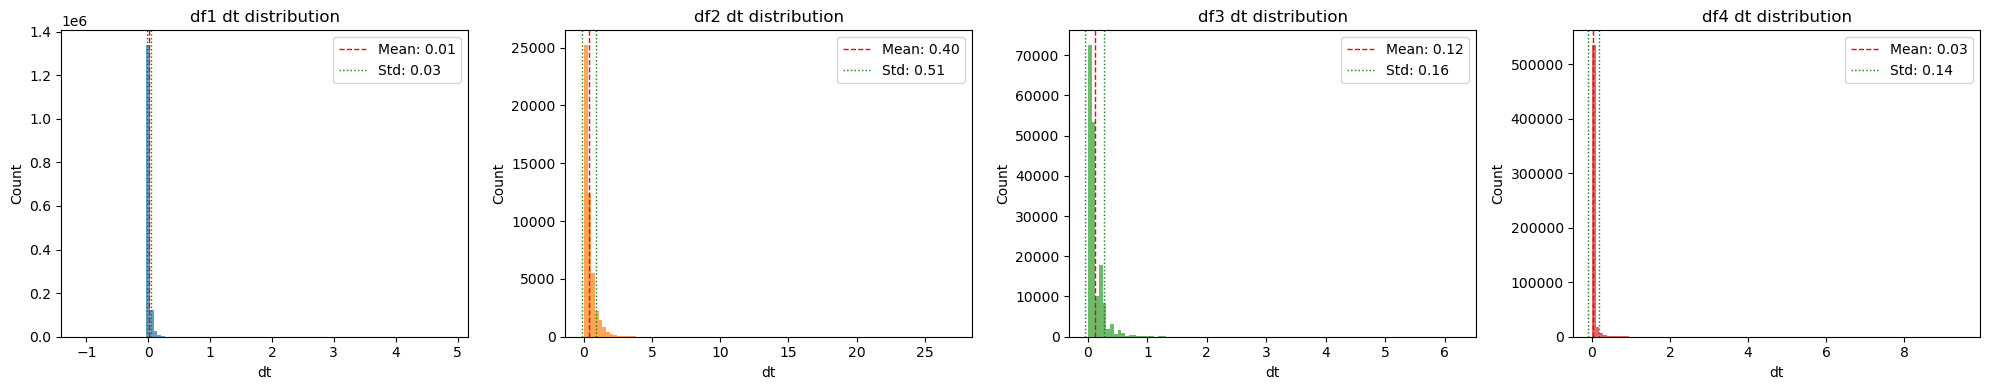

In [17]:
plt.figure(figsize=(20, 4))  # 更宽一点以容纳 4 张图

for i, (df, name) in enumerate(zip([df1, df2, df3, df4], ['df1', 'df2', 'df3', 'df4'])):
    plt.subplot(1, 4, i+1)
    dt = df['dt'].dropna()
    plt.hist(dt, bins=100, alpha=0.7, color='C'+str(i))
    mean = dt.mean()
    std = dt.std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
    plt.axvline(mean + std, color='green', linestyle='dotted', linewidth=1, label=f'Std: {std:.2f}')
    plt.axvline(mean - std, color='green', linestyle='dotted', linewidth=1)
    plt.title(f'{name} dt distribution')
    plt.xlabel('dt')
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()


In [18]:
df4['dt'].max

<bound method Series.max of 0         3.503681
1         0.022292
2         0.009259
3         0.007639
4         0.001389
            ...   
571126    0.000216
571127    0.000500
571128    0.000535
571129    0.000796
571130         NaN
Name: dt, Length: 571131, dtype: float64>

In [19]:
def load_and_filter_catalog(base_dir, Mc):
    csv_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.csv')]
    print(csv_files)
    if len(csv_files) != 1:
        raise ValueError(f"Expected exactly one csv file, but found {len(csv_files)}: {csv_files}")
    df = pd.read_csv(os.path.join(base_dir, 'raw', csv_files[0]))
    df = df[df['Magnitude'] >= Mc]
    df = df.reset_index(drop=True) # 重置索引
    return df

In [20]:
df = load_and_filter_catalog(base_dir, Mc=5.0)
print(df)

['size_3k_stress_0.6_dyn_0.8_mm_5.5_dm_0.5_b_0.4_yr_20k_EQ.csv']
               t  Magnitude  Latitude  Longitude    Depth     dt
0        250.967      5.514    23.252    102.825      0.0  0.620
1        252.727      5.127    29.250    102.276 -18000.0  1.247
2        264.206      5.115    23.278    102.834 -18000.0  0.317
3        268.577      5.128    29.277    102.278 -18000.0  0.137
4        271.264      5.259    29.250    102.276 -18000.0  0.040
...          ...        ...       ...        ...      ...    ...
23656  19994.300      5.259    24.512    103.132  -6000.0  0.100
23657  19995.500      5.121    23.919    103.070 -18000.0  0.100
23658  19997.300      5.120    23.304    102.844 -18000.0  0.000
23659  19998.900      5.239    26.448    103.046 -18000.0  0.000
23660  20000.300      5.228    26.920    102.832 -18000.0    NaN

[23661 rows x 6 columns]


In [21]:
import geopandas as gpd
import geodatasets


gdf = gpd.GeoDataFrame(
    df1,
    geometry=gpd.points_from_xy(df1['Longitude'], df1['Latitude']),
    crs="EPSG:4326" 
)
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))


fig, ax = plt.subplots(figsize=(10, 8))
world.plot(ax=ax, color='white', edgecolor='gray')  
gdf.plot(ax=ax, color='red', markersize=2, label='ChinaArray') 


plt.title("Earthquake Epicenter Distribution (ChinaArray)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'geopandas'

In [19]:
def get_time_range_from_df(df):
    """
    Extracts the timestamp from a DataFrame with separate time columns
    and returns the minimum and maximum datetime values.

    Parameters:
        df (pd.DataFrame): DataFrame with columns: 
            'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'

    Returns:
        tuple: (start_time, end_time) as pd.Timestamp objects
    """
    # Combine separate time columns into a single datetime column
    df['time'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce'  # Invalid combinations become NaT
    )

    # Drop any invalid (NaT) timestamps
    valid_times = df['time'].dropna()

    # Return the earliest and latest timestamps
    start_time = valid_times.min()
    end_time = valid_times.max()

    return start_time, end_time



In [21]:
df4

,t,Magnitude,Latitude,Longitude,Depth,dt
0,0.538380,2.7,26.050,100.980,0,3.503681
1,4.042060,7.8,24.100,102.600,13,0.022292
2,4.064352,5.2,24.200,102.450,0,0.009259
3,4.073611,4.4,24.200,102.450,0,0.007639
4,4.081250,4.3,24.200,102.450,0,0.001389
...,...,...,...,...,...,...
571126,18770.996815,0.6,25.671,99.907,8,0.000216
571127,18770.997031,1.3,25.690,99.900,8,0.000500
571128,18770.997531,1.2,25.647,99.890,8,0.000535
571129,18770.998066,0.4,25.687,99.905,8,0.000796
